
# Evaluasi Submission / Output Notebook yang Lebih Lengkap

Notebook ini adalah versi yang ditingkatkan dari evaluator sebelumnya.

Tujuan upgrade ini:

1. **Tidak cuma menghitung AW-MAE total**, tapi juga menampilkan metrik diagnostik lain.
2. **Lebih tahan error**, jadi kalau ada file yang bermasalah notebook tidak langsung berhenti.
3. Bisa dipakai untuk **membandingkan banyak submission/notebook sekaligus**.
4. Menyediakan **breakdown per grup** seperti tournament, gender, atau tahun jika kolomnya tersedia di ground truth.
5. Menampilkan **kasus-kasus error terburuk** supaya lebih mudah tahu kelemahan model.

Struktur evaluasi di notebook ini:

- leaderboard utama semua file submission
- sanity check file prediksi
- metrik detail per submission
- breakdown per grup
- worst-case rows
- perbandingan submission terhadap model referensi / model terbaik


In [31]:

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 200)



## Konfigurasi

Silakan sesuaikan bagian ini dengan struktur foldermu.

Beberapa catatan:

- `GT_PATH` mengarah ke ground truth yang akan dipakai evaluasi.
- `MANUAL_SUBMISSION_FILES` berisi daftar file prediksi yang ingin dievaluasi.
- Kalau mau otomatis mencari file `.csv`, aktifkan `USE_AUTO_DISCOVERY = True`.
- `EVAL_MODES` dibuat lebih lengkap:
  - `original_cast`: perilaku lama, mirip notebook awal (`astype(int)`).
  - `round_clip`: prediksi dibulatkan ke integer terdekat lalu di-clip minimal 0.
- `PRIMARY_MODE` adalah mode utama yang dipakai untuk breakdown detail dan worst cases.


In [32]:
GT_PATH = Path("data/ground_truth_bersih.csv")

MANUAL_SUBMISSION_FILES = [
    "best_so_far_hubert.csv",
    "submission_exp11d_best_safe.csv",
    "submission_exp04b_fix_best_safe.csv",
    "submission_exp05a_lite_best_safe.csv",
    "submission_exp05d_best_safe.csv",
    "submission_exp05c1_best_safe.csv",
    "submission_exp06b_best_safe.csv",
    "submission_exp07a_best_safe.csv",
    "submission_exp07b_best_safe.csv",
    "submission_exp08d_best_safe.csv",
    "submission_exp05a_lite_fix_v2_best_safe.csv",
    "submission_exp08d2_inplace_exp05a_full_tuning_best_safe.csv",
    "submission_exp09a_best_safe.csv",
    "submission_exp09c_best_safe.csv",
    "submission_exp09c1_best_safe.csv",
    "submission_exp09d_best_safe.csv",
    "submission_exp10a_best_safe.csv",
    "submission_exp11a_best_safe.csv",
    "submission_exp11b_best_safe.csv",
    "submission_exp11c_best_safe.csv",
    "submission_exp12a_a10_full_reproduction_advanced_base.csv",
    "submission_exp12a_a10_full_reproduction_exp15_ordinal.csv",
    "submission_exp12a_a10_full_reproduction_exp17_w_specialist.csv",
    "submission_exp12a_a10_full_reproduction.csv",
    "submission_exp12b_b5_exp15_calibrated_advanced_base.csv",
    "submission_exp12b_b5_exp15_calibrated_exp15.csv",
    "submission_exp12b_b5_exp15_calibrated.csv",
    "submission_exp12b_best_safe.csv",
    "submission_exp22_final_candidate.csv",
    "submission_exp12c_best_safe.csv",
    "submission_exp12c_c0_exp22_reproduction_advanced_base.csv",
    "submission_exp12c_c0_exp22_reproduction_exp15_ordinal.csv",
    "submission_exp12c_c0_exp22_reproduction_exp17_w_specialist.csv",
    "submission_exp12c_c0_exp22_reproduction_final_candidate.csv",
    "submission_exp12d_best_safe.csv",
    "submission_exp12d_comparison_advanced_base.csv",
    "submission_exp12d_d0_exp22_reproduction_exp15.csv",
    "submission_exp12d_d0_exp22_reproduction_exp17.csv",
    "submission_exp12d_d0_exp22_reproduction_final_candidate.csv",
    "submission_exp12d_d1_exp15_first.csv",
    "submission_exp12d_d2_exp17_original.csv",
    "submission_exp12d_d3_bias_calibrated.csv",
    "submission_exp12d_d4_outcome_calibrated.csv",
    "submission_exp12d_d5_agreement_hybrid.csv",
    "submission_exp12d_d6_exact_booster.csv",
    "submission_exp12e_e2_consensus_outcome_agree_only.csv",
    "submission_exp12f_f3_draw_to_win_cap020.csv"
    
]

USE_AUTO_DISCOVERY = False
SEARCH_DIRS = [Path("."), Path("../dump")]
AUTO_DISCOVERY_PATTERNS = ["*.csv"]
AUTO_EXCLUDE_KEYWORDS = ["ground_truth", "sample_submission", "leaderboard", "evaluation"]

EVAL_MODES = ("original_cast", "round_clip")
PRIMARY_MODE = "round_clip"
TOP_N_LEADERBOARD = 25
TOP_N_WORST_CASES = 100
OUTPUT_DIR = Path("./evaluation_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)



## Helper function evaluasi

Bagian ini berisi:

- fungsi bobot tournament
- perhitungan official loss
- validasi file
- merge GT vs prediction
- summary evaluasi yang lebih detail


In [33]:

# =========================
# 1) Tournament Weights
# =========================
def get_tournament_weight(tournament: str) -> float:
    t = str(tournament).lower().strip()
    if "fifa world cup" in t or t == "world cup":
        return 2.00
    if "afc championship" in t or "afc asian cup" in t or "asian cup" in t:
        return 1.80
    if "friendly" in t:
        return 0.96
    return 1.20


# =========================
# 2) Loss Constants
# =========================
EXACT_PENALTY = 0.30
OUTCOME_PENALTY = 0.25
GD_PENALTY = 0.15
WRONG_OUTCOME_MULTIPLIER = 1.50
NONLINEAR_POWER = 1.50


# =========================
# 3) Core helpers
# =========================
def _outcome(a: int, b: int) -> int:
    if a > b:
        return 1
    if a < b:
        return -1
    return 0


def official_match_loss(y_team_true, y_opp_true, y_team_pred, y_opp_pred):
    y_team_true = np.asarray(y_team_true).astype(int)
    y_opp_true = np.asarray(y_opp_true).astype(int)
    y_team_pred = np.asarray(y_team_pred).astype(int)
    y_opp_pred = np.asarray(y_opp_pred).astype(int)

    base_mae = (
        np.abs(y_team_true - y_team_pred) +
        np.abs(y_opp_true - y_opp_pred)
    ) / 2.0

    exact_hit = (y_team_true == y_team_pred) & (y_opp_true == y_opp_pred)
    true_outcome = np.vectorize(_outcome)(y_team_true, y_opp_true)
    pred_outcome = np.vectorize(_outcome)(y_team_pred, y_opp_pred)
    outcome_hit = (true_outcome == pred_outcome)
    gd_hit = ((y_team_true - y_opp_true) == (y_team_pred - y_opp_pred))

    penalty = (
        (~exact_hit).astype(float) * EXACT_PENALTY +
        (~outcome_hit).astype(float) * OUTCOME_PENALTY +
        (~gd_hit).astype(float) * GD_PENALTY
    )

    raw_error = base_mae + penalty
    raw_error = np.where(outcome_hit, raw_error, raw_error * WRONG_OUTCOME_MULTIPLIER)

    return raw_error ** NONLINEAR_POWER


def awmae_score(y_team_true, y_opp_true, y_team_pred, y_opp_pred, weights=None) -> float:
    losses = official_match_loss(y_team_true, y_opp_true, y_team_pred, y_opp_pred)
    if weights is None:
        weights = np.ones(len(losses), dtype=float)
    else:
        weights = np.asarray(weights, dtype=float)
    return float(np.average(losses, weights=weights))


def ensure_required_columns(df: pd.DataFrame, required_cols, df_name: str):
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"{df_name} tidak memiliki kolom wajib: {missing}. Kolom yang tersedia: {list(df.columns)}")


def read_gt(gt_path):
    gt_path = Path(gt_path)
    if not gt_path.exists():
        raise FileNotFoundError(f"Ground truth tidak ditemukan: {gt_path}")

    gt = pd.read_csv(gt_path)
    ensure_required_columns(gt, ["Id", "team_goals", "opp_goals"], "Ground truth")

    if gt["Id"].duplicated().any():
        dup = gt.loc[gt["Id"].duplicated(), "Id"].tolist()[:10]
        raise ValueError(f"Ground truth memiliki Id duplikat. Contoh: {dup}")

    gt = gt.copy()
    gt["team_goals"] = pd.to_numeric(gt["team_goals"], errors="raise")
    gt["opp_goals"] = pd.to_numeric(gt["opp_goals"], errors="raise")
    return gt


def read_pred(pred_path):
    pred_path = Path(pred_path)
    if not pred_path.exists():
        raise FileNotFoundError(f"Prediction file tidak ditemukan: {pred_path}")

    pred = pd.read_csv(pred_path)
    ensure_required_columns(pred, ["Id", "team_goals", "opp_goals"], f"Prediction file: {pred_path.name}")
    return pred


def discover_submission_files(search_dirs, patterns=("*.csv",), exclude_keywords=None):
    files = []
    exclude_keywords = exclude_keywords or []
    for base_dir in search_dirs:
        base_dir = Path(base_dir)
        if not base_dir.exists():
            continue
        for pattern in patterns:
            for p in base_dir.rglob(pattern):
                name_lower = p.name.lower()
                if any(k.lower() in name_lower for k in exclude_keywords):
                    continue
                files.append(p)
    files = sorted(set(files))
    return files


def collect_submission_paths(manual_files=None, use_auto=False, search_dirs=None, patterns=("*.csv",), exclude_keywords=None):
    paths = []
    for item in manual_files or []:
        paths.append(Path(item))
    if use_auto:
        paths.extend(discover_submission_files(search_dirs or [], patterns=patterns, exclude_keywords=exclude_keywords))

    # unique sambil menjaga urutan
    seen = set()
    final_paths = []
    for p in paths:
        p_resolved = Path(p)
        if str(p_resolved) not in seen:
            seen.add(str(p_resolved))
            final_paths.append(p_resolved)
    return final_paths


def sanitize_pred_numeric(pred: pd.DataFrame) -> pd.DataFrame:
    out = pred.copy()
    out["team_goals_raw"] = pd.to_numeric(out["team_goals"], errors="coerce")
    out["opp_goals_raw"] = pd.to_numeric(out["opp_goals"], errors="coerce")

    if out[["team_goals_raw", "opp_goals_raw"]].isna().any().any():
        bad_rows = out[out[["team_goals_raw", "opp_goals_raw"]].isna().any(axis=1)].head(5)
        raise ValueError(
            "Ada nilai prediksi yang tidak bisa diubah menjadi numerik. "
            f"Contoh baris bermasalah:\n{bad_rows}"
        )
    return out


def make_eval_predictions(pred: pd.DataFrame, mode: str) -> pd.DataFrame:
    out = sanitize_pred_numeric(pred)

    if mode == "original_cast":
        out["team_goals_eval"] = out["team_goals_raw"].astype(int)
        out["opp_goals_eval"] = out["opp_goals_raw"].astype(int)
    elif mode == "round_clip":
        out["team_goals_eval"] = np.clip(np.rint(out["team_goals_raw"]), 0, None).astype(int)
        out["opp_goals_eval"] = np.clip(np.rint(out["opp_goals_raw"]), 0, None).astype(int)
    else:
        raise ValueError(f"Mode evaluasi tidak dikenal: {mode}")

    return out


def build_row_level_detail(gt: pd.DataFrame, pred: pd.DataFrame, mode: str) -> pd.DataFrame:
    pred_eval = make_eval_predictions(pred, mode=mode)

    df = gt.merge(
        pred_eval[["Id", "team_goals_raw", "opp_goals_raw", "team_goals_eval", "opp_goals_eval"]],
        on="Id",
        how="left"
    ).copy()

    df["missing_prediction"] = df[["team_goals_eval", "opp_goals_eval"]].isna().any(axis=1)

    if df["missing_prediction"].any():
        missing_ids = df.loc[df["missing_prediction"], "Id"].tolist()[:10]
        raise ValueError(f"Ada Id dari ground truth yang tidak ditemukan di prediction file. Contoh: {missing_ids}")

    df["team_goals_true"] = pd.to_numeric(df["team_goals"], errors="raise").astype(int)
    df["opp_goals_true"] = pd.to_numeric(df["opp_goals"], errors="raise").astype(int)
    df["team_goals_pred"] = df["team_goals_eval"].astype(int)
    df["opp_goals_pred"] = df["opp_goals_eval"].astype(int)

    df["team_abs_err"] = np.abs(df["team_goals_true"] - df["team_goals_pred"])
    df["opp_abs_err"] = np.abs(df["opp_goals_true"] - df["opp_goals_pred"])
    df["base_mae"] = (df["team_abs_err"] + df["opp_abs_err"]) / 2.0

    df["true_outcome"] = np.vectorize(_outcome)(df["team_goals_true"], df["opp_goals_true"])
    df["pred_outcome"] = np.vectorize(_outcome)(df["team_goals_pred"], df["opp_goals_pred"])

    df["exact_hit"] = (
        (df["team_goals_true"] == df["team_goals_pred"]) &
        (df["opp_goals_true"] == df["opp_goals_pred"])
    )
    df["outcome_hit"] = df["true_outcome"] == df["pred_outcome"]
    df["gd_hit"] = (
        (df["team_goals_true"] - df["opp_goals_true"]) ==
        (df["team_goals_pred"] - df["opp_goals_pred"])
    )

    df["penalty_exact"] = (~df["exact_hit"]).astype(float) * EXACT_PENALTY
    df["penalty_outcome"] = (~df["outcome_hit"]).astype(float) * OUTCOME_PENALTY
    df["penalty_gd"] = (~df["gd_hit"]).astype(float) * GD_PENALTY
    df["penalty_total"] = df[["penalty_exact", "penalty_outcome", "penalty_gd"]].sum(axis=1)

    df["raw_error_before_multiplier"] = df["base_mae"] + df["penalty_total"]
    df["wrong_outcome_multiplier"] = np.where(df["outcome_hit"], 1.0, WRONG_OUTCOME_MULTIPLIER)
    df["raw_error_after_multiplier"] = df["raw_error_before_multiplier"] * df["wrong_outcome_multiplier"]
    df["official_loss"] = df["raw_error_after_multiplier"] ** NONLINEAR_POWER

    if "tournament" in df.columns:
        df["tournament_weight"] = df["tournament"].apply(get_tournament_weight)
    else:
        df["tournament_weight"] = 1.0

    df["weighted_official_loss"] = df["official_loss"] * df["tournament_weight"]
    df["team_bias"] = df["team_goals_pred"] - df["team_goals_true"]
    df["opp_bias"] = df["opp_goals_pred"] - df["opp_goals_true"]
    df["total_goals_true"] = df["team_goals_true"] + df["opp_goals_true"]
    df["total_goals_pred"] = df["team_goals_pred"] + df["opp_goals_pred"]
    df["total_goals_abs_err"] = np.abs(df["total_goals_true"] - df["total_goals_pred"])
    df["goal_diff_true"] = df["team_goals_true"] - df["opp_goals_true"]
    df["goal_diff_pred"] = df["team_goals_pred"] - df["opp_goals_pred"]
    df["goal_diff_abs_err"] = np.abs(df["goal_diff_true"] - df["goal_diff_pred"])

    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
        df["year"] = df["date"].dt.year

    return df


def summarize_detail_df(df: pd.DataFrame, pred_raw: pd.DataFrame, pred_path: Path, mode: str) -> dict:
    gt_ids = set(df["Id"])
    pred_ids = set(pred_raw["Id"])

    duplicate_pred_ids = int(pred_raw["Id"].duplicated().sum())
    missing_in_pred = len(gt_ids - pred_ids)
    extra_in_pred = len(pred_ids - gt_ids)

    raw_numeric = sanitize_pred_numeric(pred_raw)
    summary = {
        "file": str(pred_path),
        "file_name": pred_path.name,
        "stem": pred_path.stem,
        "mode": mode,
        "n_gt": int(len(df)),
        "n_pred_rows": int(len(pred_raw)),
        "n_unique_pred_ids": int(pred_raw["Id"].nunique()),
        "duplicate_pred_ids": duplicate_pred_ids,
        "missing_in_pred": int(missing_in_pred),
        "extra_in_pred": int(extra_in_pred),
        "coverage_ratio": float(len(gt_ids & pred_ids) / max(len(gt_ids), 1)),
        "negative_team_pred_raw": int((raw_numeric["team_goals_raw"] < 0).sum()),
        "negative_opp_pred_raw": int((raw_numeric["opp_goals_raw"] < 0).sum()),
        "team_pred_raw_min": float(raw_numeric["team_goals_raw"].min()),
        "team_pred_raw_max": float(raw_numeric["team_goals_raw"].max()),
        "opp_pred_raw_min": float(raw_numeric["opp_goals_raw"].min()),
        "opp_pred_raw_max": float(raw_numeric["opp_goals_raw"].max()),
        "awmae": float(np.average(df["official_loss"], weights=df["tournament_weight"])),
        "mae_base": float(df["base_mae"].mean()),
        "mean_official_loss_unweighted": float(df["official_loss"].mean()),
        "exact_rate": float(df["exact_hit"].mean()),
        "outcome_rate": float(df["outcome_hit"].mean()),
        "gd_rate": float(df["gd_hit"].mean()),
        "avg_penalty_exact": float(df["penalty_exact"].mean()),
        "avg_penalty_outcome": float(df["penalty_outcome"].mean()),
        "avg_penalty_gd": float(df["penalty_gd"].mean()),
        "avg_penalty_total": float(df["penalty_total"].mean()),
        "team_bias_mean": float(df["team_bias"].mean()),
        "opp_bias_mean": float(df["opp_bias"].mean()),
        "team_abs_err_mean": float(df["team_abs_err"].mean()),
        "opp_abs_err_mean": float(df["opp_abs_err"].mean()),
        "total_goals_abs_err_mean": float(df["total_goals_abs_err"].mean()),
        "goal_diff_abs_err_mean": float(df["goal_diff_abs_err"].mean()),
    }
    return summary


def evaluate_submission_detailed(gt_path, pred_path, eval_modes=("original_cast", "round_clip")):
    gt = read_gt(gt_path)
    pred = read_pred(pred_path)

    if pred["Id"].duplicated().any():
        dup_ids = pred.loc[pred["Id"].duplicated(), "Id"].astype(str).tolist()[:10]
        raise ValueError(f"Prediction file memiliki Id duplikat. Contoh: {dup_ids}")

    mode_summaries = []
    mode_details = {}

    for mode in eval_modes:
        detail_df = build_row_level_detail(gt=gt, pred=pred, mode=mode)
        summary = summarize_detail_df(detail_df, pred_raw=pred, pred_path=Path(pred_path), mode=mode)
        mode_summaries.append(summary)
        mode_details[mode] = detail_df

    summary_df = pd.DataFrame(mode_summaries).sort_values("awmae", ascending=True).reset_index(drop=True)
    best_mode = summary_df.loc[0, "mode"]

    combined = {
        "file": str(pred_path),
        "file_name": Path(pred_path).name,
        "stem": Path(pred_path).stem,
        "best_mode": best_mode,
        "best_awmae": float(summary_df.loc[0, "awmae"]),
    }

    for _, row in summary_df.iterrows():
        prefix = row["mode"]
        for col, val in row.items():
            if col in {"file", "file_name", "stem", "mode"}:
                continue
            combined[f"{prefix}__{col}"] = val

    best_df = mode_details[best_mode].copy()
    return combined, summary_df, mode_details, best_df


def safe_evaluate_submission(gt_path, pred_path, eval_modes=("original_cast", "round_clip")):
    try:
        combined, summary_df, mode_details, best_df = evaluate_submission_detailed(
            gt_path=gt_path,
            pred_path=pred_path,
            eval_modes=eval_modes,
        )
        combined["status"] = "ok"
        combined["error"] = None
        return combined, summary_df, mode_details, best_df
    except Exception as e:
        return {
            "file": str(pred_path),
            "file_name": Path(pred_path).name,
            "stem": Path(pred_path).stem,
            "best_mode": None,
            "best_awmae": np.nan,
            "status": "error",
            "error": str(e),
        }, None, None, None


def group_breakdown(detail_df: pd.DataFrame, group_col: str) -> pd.DataFrame:
    if group_col not in detail_df.columns:
        return pd.DataFrame()

    tmp = detail_df.copy()
    tmp[group_col] = tmp[group_col].fillna("<NA>")

    rows = []
    for key, part in tmp.groupby(group_col, dropna=False):
        rows.append({
            group_col: key,
            "n": int(len(part)),
            "awmae": float(np.average(part["official_loss"], weights=part["tournament_weight"])),
            "mae_base": float(part["base_mae"].mean()),
            "exact_rate": float(part["exact_hit"].mean()),
            "outcome_rate": float(part["outcome_hit"].mean()),
            "gd_rate": float(part["gd_hit"].mean()),
            "team_bias_mean": float(part["team_bias"].mean()),
            "opp_bias_mean": float(part["opp_bias"].mean()),
            "avg_penalty_total": float(part["penalty_total"].mean()),
        })

    out = pd.DataFrame(rows).sort_values(["awmae", "n"], ascending=[True, False]).reset_index(drop=True)
    return out


def make_reference_comparison(details_store: dict, reference_file: str) -> pd.DataFrame:
    if reference_file not in details_store:
        return pd.DataFrame()

    ref_df = details_store[reference_file]["best_df"][["Id", "official_loss"]].rename(columns={"official_loss": "ref_loss"})
    rows = []
    for file_key, payload in details_store.items():
        cand = payload["best_df"][["Id", "official_loss"]].rename(columns={"official_loss": "cand_loss"})
        merged = ref_df.merge(cand, on="Id", how="inner")
        rows.append({
            "file": file_key,
            "avg_delta_vs_reference": float((merged["cand_loss"] - merged["ref_loss"]).mean()),
            "row_better_than_reference_rate": float((merged["cand_loss"] < merged["ref_loss"]).mean()),
            "row_equal_to_reference_rate": float((merged["cand_loss"] == merged["ref_loss"]).mean()),
        })
    out = pd.DataFrame(rows).sort_values("avg_delta_vs_reference", ascending=True).reset_index(drop=True)
    return out



## Jalankan evaluasi semua file

Cell ini akan:

- mengumpulkan file prediksi
- mengevaluasi satu per satu
- menyimpan hasil ringkas dan detail
- tetap lanjut walaupun ada file yang error


In [34]:

submission_paths = collect_submission_paths(
    manual_files=MANUAL_SUBMISSION_FILES,
    use_auto=USE_AUTO_DISCOVERY,
    search_dirs=SEARCH_DIRS,
    patterns=AUTO_DISCOVERY_PATTERNS,
    exclude_keywords=AUTO_EXCLUDE_KEYWORDS,
)

print(f"Jumlah file yang akan dicek: {len(submission_paths)}")
for p in submission_paths:
    print("-", p)

summary_rows = []
mode_summary_store = {}
details_store = {}

for pred_path in submission_paths:
    combined, summary_df, mode_details, best_df = safe_evaluate_submission(
        gt_path=GT_PATH,
        pred_path=pred_path,
        eval_modes=EVAL_MODES,
    )
    summary_rows.append(combined)

    if combined.get("status") == "ok":
        mode_summary_store[str(pred_path)] = summary_df
        details_store[str(pred_path)] = {
            "mode_summary_df": summary_df,
            "mode_details": mode_details,
            "best_df": best_df,
            "best_mode": combined["best_mode"],
            "best_awmae": combined["best_awmae"],
        }

leaderboard_all = pd.DataFrame(summary_rows)
leaderboard_ok = leaderboard_all[leaderboard_all["status"] == "ok"].copy()
leaderboard_err = leaderboard_all[leaderboard_all["status"] != "ok"].copy()

if not leaderboard_ok.empty:
    leaderboard_ok = leaderboard_ok.sort_values("best_awmae", ascending=True).reset_index(drop=True)

leaderboard_all.to_csv(OUTPUT_DIR / "leaderboard_all.csv", index=False)
if not leaderboard_ok.empty:
    leaderboard_ok.to_csv(OUTPUT_DIR / "leaderboard_ok.csv", index=False)
if not leaderboard_err.empty:
    leaderboard_err.to_csv(OUTPUT_DIR / "leaderboard_error.csv", index=False)


Jumlah file yang akan dicek: 47
- best_so_far_hubert.csv
- submission_exp11d_best_safe.csv
- submission_exp04b_fix_best_safe.csv
- submission_exp05a_lite_best_safe.csv
- submission_exp05d_best_safe.csv
- submission_exp05c1_best_safe.csv
- submission_exp06b_best_safe.csv
- submission_exp07a_best_safe.csv
- submission_exp07b_best_safe.csv
- submission_exp08d_best_safe.csv
- submission_exp05a_lite_fix_v2_best_safe.csv
- submission_exp08d2_inplace_exp05a_full_tuning_best_safe.csv
- submission_exp09a_best_safe.csv
- submission_exp09c_best_safe.csv
- submission_exp09c1_best_safe.csv
- submission_exp09d_best_safe.csv
- submission_exp10a_best_safe.csv
- submission_exp11a_best_safe.csv
- submission_exp11b_best_safe.csv
- submission_exp11c_best_safe.csv
- submission_exp12a_a10_full_reproduction_advanced_base.csv
- submission_exp12a_a10_full_reproduction_exp15_ordinal.csv
- submission_exp12a_a10_full_reproduction_exp17_w_specialist.csv
- submission_exp12a_a10_full_reproduction.csv
- submission_ex


## Leaderboard utama

Kolom yang paling penting untuk dibaca:

- `best_awmae`: skor terbaik file tersebut dari mode evaluasi yang dicoba
- `best_mode`: mode evaluasi terbaiknya
- `round_clip__awmae`: biasanya ini yang lebih aman kalau ada output float
- `exact_rate`: seberapa sering skor tepat persis
- `outcome_rate`: seberapa sering win/draw/loss benar
- `gd_rate`: seberapa sering selisih gol benar
- `team_bias_mean` dan `opp_bias_mean`: apakah model cenderung overpredict atau underpredict


In [35]:

if leaderboard_ok.empty:
    print("Belum ada file yang berhasil dievaluasi. Cek GT path dan file submission.")
else:
    important_cols = [
        "file_name",
        "best_mode",
        "best_awmae",
        "original_cast__awmae",
        "round_clip__awmae",
        "round_clip__mae_base",
        "round_clip__exact_rate",
        "round_clip__outcome_rate",
        "round_clip__gd_rate",
        "round_clip__team_bias_mean",
        "round_clip__opp_bias_mean",
        "round_clip__duplicate_pred_ids",
        "round_clip__missing_in_pred",
        "round_clip__extra_in_pred",
        "status",
    ]
    important_cols = [c for c in important_cols if c in leaderboard_ok.columns]
    display(leaderboard_ok[important_cols].head(TOP_N_LEADERBOARD))

if not leaderboard_err.empty:
    print("\nFile yang error saat evaluasi:")
    display(leaderboard_err[["file_name", "error"]])


,file_name,best_mode,best_awmae,original_cast__awmae,round_clip__awmae,round_clip__mae_base,round_clip__exact_rate,round_clip__outcome_rate,round_clip__gd_rate,round_clip__team_bias_mean,round_clip__opp_bias_mean,round_clip__duplicate_pred_ids,round_clip__missing_in_pred,round_clip__extra_in_pred,status
0,submission_exp12f_f3_draw_to_win_cap020.csv,original_cast,2.991999,2.991999,2.991999,1.025458,0.108057,0.586111,0.224176,-0.177172,-0.177172,0,0,0,ok
1,submission_exp22_final_candidate.csv,original_cast,2.996820,2.996820,2.996820,1.024138,0.109189,0.583141,0.223658,-0.195135,-0.195135,0,0,0,ok
2,submission_exp12e_e2_consensus_outcome_agree_only.csv,original_cast,2.998319,2.998319,2.998319,1.024421,0.108151,0.582528,0.224978,-0.174721,-0.174721,0,0,0,ok
3,submission_exp12d_best_safe.csv,original_cast,2.999642,2.999642,2.999642,1.024516,0.108151,0.582528,0.224789,-0.171939,-0.171939,0,0,0,ok
4,submission_exp12d_d0_exp22_reproduction_exp15.csv,original_cast,3.003729,3.003729,3.003729,1.024162,0.107633,0.580218,0.224459,-0.164325,-0.179176,0,0,0,ok
5,submission_exp12c_c0_exp22_reproduction_exp15_ordinal.csv,original_cast,3.003729,3.003729,3.003729,1.024162,0.107633,0.580218,0.224459,-0.164325,-0.179176,0,0,0,ok
6,submission_exp12d_d5_agreement_hybrid.csv,original_cast,3.003729,3.003729,3.003729,1.024162,0.107633,0.580218,0.224459,-0.164325,-0.179176,0,0,0,ok
7,submission_exp12d_d1_exp15_first.csv,original_cast,3.003729,3.003729,3.003729,1.024162,0.107633,0.580218,0.224459,-0.164325,-0.179176,0,0,0,ok
8,submission_exp12c_c0_exp22_reproduction_exp17_w_specialist.csv,original_cast,3.005646,3.005646,3.005646,1.026401,0.106926,0.583471,0.224318,-0.132384,-0.132384,0,0,0,ok
9,submission_exp12d_d0_exp22_reproduction_exp17.csv,original_cast,3.005646,3.005646,3.005646,1.026401,0.106926,0.583471,0.224318,-0.132384,-0.132384,0,0,0,ok



## Visualisasi leaderboard


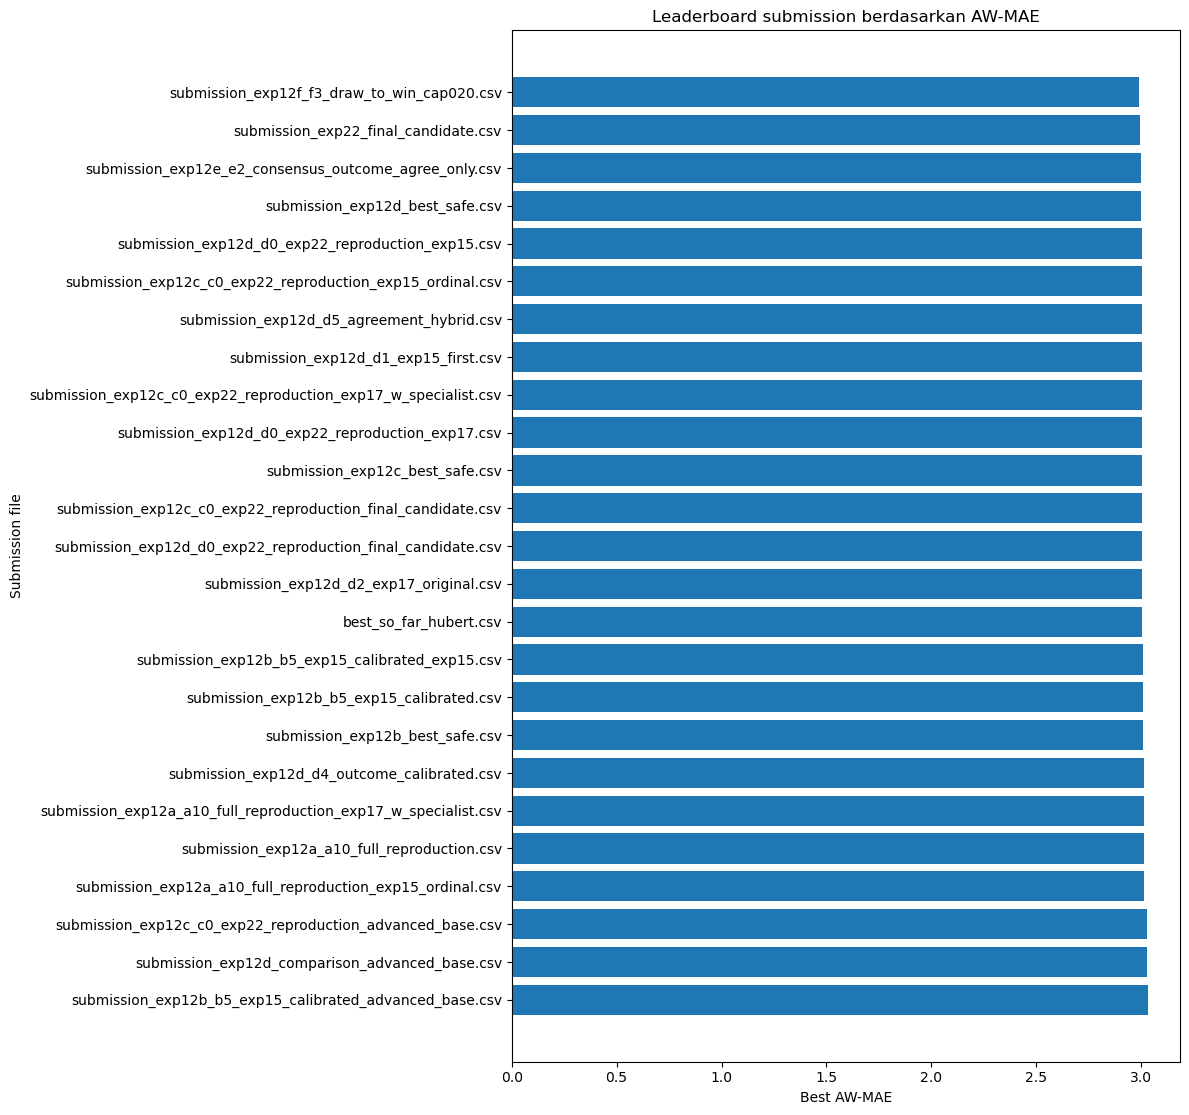

In [36]:

if not leaderboard_ok.empty:
    top_plot = leaderboard_ok.head(min(TOP_N_LEADERBOARD, len(leaderboard_ok))).copy()
    plt.figure(figsize=(12, max(4, 0.45 * len(top_plot))))
    plt.barh(top_plot["file_name"], top_plot["best_awmae"])
    plt.gca().invert_yaxis()
    plt.xlabel("Best AW-MAE")
    plt.ylabel("Submission file")
    plt.title("Leaderboard submission berdasarkan AW-MAE")
    plt.tight_layout()
    plt.show()



## Lihat detail mode evaluasi per file

Cell ini berguna kalau kamu ingin tahu, untuk satu file tertentu, apakah `original_cast` atau `round_clip` lebih masuk akal.


In [37]:

if not leaderboard_ok.empty:
    selected_file = leaderboard_ok.loc[0, "file"]
    print("File yang sedang diinspeksi:", selected_file)
    display(mode_summary_store[selected_file])


File yang sedang diinspeksi: submission_exp12f_f3_draw_to_win_cap020.csv


,file,file_name,stem,mode,n_gt,n_pred_rows,n_unique_pred_ids,duplicate_pred_ids,missing_in_pred,extra_in_pred,coverage_ratio,negative_team_pred_raw,negative_opp_pred_raw,team_pred_raw_min,team_pred_raw_max,opp_pred_raw_min,opp_pred_raw_max,awmae,mae_base,mean_official_loss_unweighted,exact_rate,outcome_rate,gd_rate,avg_penalty_exact,avg_penalty_outcome,avg_penalty_gd,avg_penalty_total,team_bias_mean,opp_bias_mean,team_abs_err_mean,opp_abs_err_mean,total_goals_abs_err_mean,goal_diff_abs_err_mean
0,submission_exp12f_f3_draw_to_win_cap020.csv,submission_exp12f_f3_draw_to_win_cap020.csv,submission_exp12f_f3_draw_to_win_cap020,original_cast,42422,42422,42422,0,0,0,1.0,0,0,0.0,10.0,0.0,10.0,2.991999,1.025458,2.991999,0.108057,0.586111,0.224176,0.267583,0.103472,0.116374,0.487429,-0.177172,-0.177172,1.025458,1.025458,1.59521,1.603602
1,submission_exp12f_f3_draw_to_win_cap020.csv,submission_exp12f_f3_draw_to_win_cap020.csv,submission_exp12f_f3_draw_to_win_cap020,round_clip,42422,42422,42422,0,0,0,1.0,0,0,0.0,10.0,0.0,10.0,2.991999,1.025458,2.991999,0.108057,0.586111,0.224176,0.267583,0.103472,0.116374,0.487429,-0.177172,-0.177172,1.025458,1.025458,1.59521,1.603602



## Breakdown detail untuk model terbaik

Bagian ini membantu menjawab pertanyaan seperti:

- model paling jelek di tournament apa?
- apakah performa beda jauh antara gender tertentu?
- tahun mana yang paling sulit?


In [38]:

if not leaderboard_ok.empty:
    best_file = leaderboard_ok.loc[0, "file"]
    best_payload = details_store[best_file]
    best_df = best_payload["best_df"].copy()

    print("Best file:", best_file)
    print("Best mode:", best_payload["best_mode"])
    print("Best AW-MAE:", round(best_payload["best_awmae"], 6))

    group_candidates = ["tournament", "gender", "year", "home_team", "away_team"]
    for col in group_candidates:
        breakdown = group_breakdown(best_df, col)
        if not breakdown.empty:
            print(f"\nBreakdown by {col}:")
            display(breakdown.head(20))
            breakdown.to_csv(OUTPUT_DIR / f"best_model_breakdown_by_{col}.csv", index=False)


Best file: submission_exp12f_f3_draw_to_win_cap020.csv
Best mode: original_cast
Best AW-MAE: 2.991999



## Worst-case rows dari model terbaik

Ini penting karena dari sini biasanya kita bisa tahu pola error terbesar, misalnya:

- pertandingan dengan skor besar
- pertandingan tertentu yang outcome-nya salah total
- turnamen tertentu yang sulit


In [39]:

if not leaderboard_ok.empty:
    best_file = leaderboard_ok.loc[0, "file"]
    best_df = details_store[best_file]["best_df"].copy()

    cols_to_show = [
        "Id",
        "date",
        "tournament",
        "gender",
        "home_team",
        "away_team",
        "team_goals_true",
        "opp_goals_true",
        "team_goals_pred",
        "opp_goals_pred",
        "base_mae",
        "penalty_total",
        "official_loss",
        "exact_hit",
        "outcome_hit",
        "gd_hit",
        "team_bias",
        "opp_bias",
    ]
    cols_to_show = [c for c in cols_to_show if c in best_df.columns]

    worst_cases = best_df.sort_values("official_loss", ascending=False).head(TOP_N_WORST_CASES)
    display(worst_cases[cols_to_show])
    worst_cases[cols_to_show].to_csv(OUTPUT_DIR / "best_model_worst_cases.csv", index=False)


,Id,team_goals_true,opp_goals_true,team_goals_pred,opp_goals_pred,base_mae,penalty_total,official_loss,exact_hit,outcome_hit,gd_hit,team_bias,opp_bias
7457,M037762_South Ossetia,19,0,1,2,10.0,0.70,64.300234,False,False,False,-18,2
7456,M037762_Darfur,0,19,2,1,10.0,0.70,64.300234,False,False,False,2,-18
37396,W010269_Maldives,0,13,2,1,7.0,0.70,39.253011,False,False,False,2,-12
37397,W010269_Bhutan,13,0,1,2,7.0,0.70,39.253011,False,False,False,-12,2
12896,M039676_Chagos Islands,0,12,2,1,6.5,0.70,35.492422,False,False,False,2,-11
29649,W008804_Sápmi,13,1,1,2,6.5,0.70,35.492422,False,False,False,-12,1
29648,W008804_Tibet,1,13,2,1,6.5,0.70,35.492422,False,False,False,1,-12
12897,M039676_Western Armenia,12,0,1,2,6.5,0.70,35.492422,False,False,False,-11,2
7522,M037795_Darfur,0,12,2,1,6.5,0.70,35.492422,False,False,False,2,-11
7523,M037795_Artsakh,12,0,1,2,6.5,0.70,35.492422,False,False,False,-11,2



## Perbandingan terhadap model referensi / model terbaik

Interpretasi kolom:

- `avg_delta_vs_reference < 0`: rata-rata model ini lebih baik daripada referensi
- `row_better_than_reference_rate`: proporsi baris dimana loss model ini lebih kecil daripada referensi

Secara default, referensi yang dipakai adalah model terbaik di leaderboard.


In [40]:

if not leaderboard_ok.empty:
    reference_file = leaderboard_ok.loc[0, "file"]
    comparison_df = make_reference_comparison(details_store, reference_file=reference_file)
    print("Reference file:", reference_file)
    display(comparison_df)
    comparison_df.to_csv(OUTPUT_DIR / "comparison_vs_reference.csv", index=False)


Reference file: submission_exp12f_f3_draw_to_win_cap020.csv


,file,avg_delta_vs_reference,row_better_than_reference_rate,row_equal_to_reference_rate
0,submission_exp12f_f3_draw_to_win_cap020.csv,0.000000,0.000000,1.000000
1,submission_exp22_final_candidate.csv,0.004821,0.088633,0.823064
2,submission_exp12e_e2_consensus_outcome_agree_only.csv,0.006320,0.010513,0.980010
3,submission_exp12d_best_safe.csv,0.007643,0.013248,0.974353
4,submission_exp12d_d0_exp22_reproduction_exp15.csv,0.011730,0.017915,0.964759
5,submission_exp12c_c0_exp22_reproduction_exp15_ordinal.csv,0.011730,0.017915,0.964759
6,submission_exp12d_d5_agreement_hybrid.csv,0.011730,0.017915,0.964759
7,submission_exp12d_d1_exp15_first.csv,0.011730,0.017915,0.964759
8,submission_exp12c_c0_exp22_reproduction_exp17_w_specialist.csv,0.013647,0.038188,0.920372
9,submission_exp12d_d0_exp22_reproduction_exp17.csv,0.013647,0.038188,0.920372



## Ringkasan interpretasi

Checklist membaca hasil evaluasi:

1. **Lihat `best_awmae`** untuk ranking utama.
2. **Bandingkan `mae_base` vs `official_loss`**. Kalau `mae_base` tidak terlalu buruk tapi `official_loss` tinggi, biasanya masalah ada di outcome / goal difference / exact score penalty.
3. **Lihat `exact_rate`, `outcome_rate`, `gd_rate`** untuk tahu model kuat di aspek mana.
4. **Lihat bias**:
   - `team_bias_mean > 0` artinya cenderung overpredict gol tim
   - `team_bias_mean < 0` artinya cenderung underpredict gol tim
5. **Lihat breakdown per tournament / gender / year** untuk mencari domain yang masih lemah.
6. **Lihat worst cases** untuk menentukan eksperimen lanjutan.

Contoh ide tindak lanjut setelah evaluasi:

- kalau lemah di tournament tertentu → coba model/domain split per tournament
- kalau outcome sering salah → tambahkan objective yang lebih fokus ke direction win/draw/loss
- kalau exact rate rendah tapi outcome rate lumayan → mungkin post-processing scoreline perlu diperbaiki
- kalau bias gol terlalu tinggi/rendah → cek calibration atau clipping prediksi
